# Análisis de resultados

Predicción de metalicidad gaseosa desde imágenes *gri* de SDSS.

Este notebook **no repite** lo que ya genera `scripts/04_evaluar.py` (métricas y
figuras básicas). Va a la pregunta científica de fondo:

> ¿La CNN está aprendiendo algo más que la relación masa-metalicidad?

Es la pregunta central de la §6.2 de [Wu & Boada (2019)](https://arxiv.org/abs/1810.12913).
Si el modelo solo estuviera estimando la masa estelar de la imagen y aplicando
el MZR, su error debería ser *mayor* que el de un predictor que ya conoce la masa
verdadera. Acá se compara directamente contra ese predictor.

**Requisito:** haber corrido los cuatro pasos del pipeline. Ver [README](../README.md)
y [docs/metodologia.md](../docs/metodologia.md).

In [1]:
# El nombre de la corrida a analizar: la subcarpeta dentro de results/
NOMBRE = "resnet34"

In [2]:
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, "../src")
from gasmet.config import cargar, ruta_absoluta
from gasmet.evaluate import metricas, metricas_por_bin, nmad
from gasmet.plots import AQUA, AZUL, DENSIDAD, NARANJO, TINTA, TINTA_SUAVE, _estilo

# gasmet.plots fija el backend Agg al importarse, porque los nodos del cluster
# no tienen display. Dentro del notebook hay que volver al backend inline, o
# plt.show() no dibuja nada. El orden importa: esta linea va DESPUES del import.
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
_estilo()

cfg = cargar("../config.yaml")
RESULTADOS = ruta_absoluta(cfg.entrenamiento.dir_resultados) / NOMBRE

# Referencia del paper.
WU_RMSE, WU_NMAD = 0.085, 0.067


In [3]:
preds = np.load(RESULTADOS / "predicciones_test.npz")
y_real, y_pred = preds["y_real"], preds["y_pred"]

met = json.loads((RESULTADOS / "metricas.json").read_text(encoding="utf-8"))
hist = json.loads((RESULTADOS / "historial.json").read_text(encoding="utf-8"))
meta = pd.read_parquet(ruta_absoluta("data/processed/metadatos.parquet"))

test = meta[meta["split"] == "test"].reset_index(drop=True)
assert len(test) == len(y_real), "metadatos y predicciones no calzan"

print(f"Test: {len(y_real):,} galaxias")
print(f"Entrenamiento: {hist['segundos']/60:.1f} min, "
      f"mejor en la época {hist['epoca_mejor']} de {len(hist['train_loss'])}")

Test: 14,998 galaxias
Entrenamiento: 15.2 min, mejor en la época 27 de 37


## 1. El resultado, en contexto

Tres cifras importan, y ninguna sola basta:

- **El baseline de predecir la media.** Es el piso. Un modelo que no lo supere no
  extrae información de las imágenes, por bueno que se vea su R².
- **El MZR con masa verdadera.** El competidor honesto: ¿le gana la CNN a alguien
  que ya sabe la masa estelar?
- **Wu & Boada.** El techo de referencia.

In [4]:
# --- Baseline 1: predecir siempre la media del train ---
y_train = meta.loc[meta["split"] == "train", "metalicidad"].to_numpy()
m_media = metricas(y_real, np.full_like(y_real, y_train.mean()))

# --- Baseline 2: el MZR de Tremonti+04 aplicado a la masa VERDADERA ---
# Z = -1.492 + 1.847 log(M) - 0.08026 [log(M)]^2      (Tremonti et al. 2004, ec. 3)
#
# Es un competidor exigente: usa la masa estelar medida espectroscópicamente,
# que la CNN nunca ve. Si la red le gana, está usando información que va más
# allá de la relación masa-metalicidad.
def mzr_tremonti(log_masa):
    return -1.492 + 1.847 * log_masa - 0.08026 * log_masa**2

masa_ok = np.isfinite(test["log_masa"]) & (test["log_masa"] > 7)
m_mzr = metricas(y_real[masa_ok], mzr_tremonti(test.loc[masa_ok, "log_masa"].to_numpy()))

# --- El modelo ---
m_cnn = met["test"]

resumen = pd.DataFrame([
    {"modelo": "Predecir la media (baseline)", **m_media},
    {"modelo": "MZR Tremonti+04 con masa real", **m_mzr},
    {"modelo": "CNN (este trabajo)", **m_cnn},
    {"modelo": "Wu & Boada 2019", "rmse_dex": WU_RMSE, "nmad_dex": WU_NMAD,
     "mae_dex": np.nan, "sesgo_dex": np.nan, "r2": np.nan, "n": 20466},
])
resumen = resumen[["modelo", "rmse_dex", "nmad_dex", "mae_dex", "sesgo_dex", "r2", "n"]]
resumen.round(4)

,modelo,rmse_dex,nmad_dex,mae_dex,sesgo_dex,r2,n
0,Predecir la media (baseline),0.1881,0.1553,0.1426,0.0030,-0.0002,14998
1,MZR Tremonti+04 con masa real,0.1253,0.0939,0.0863,0.0044,0.5566,14990
2,CNN (este trabajo),0.0841,0.0624,0.0590,0.0022,0.8002,14998
3,Wu & Boada 2019,0.0850,0.0670,NaN,NaN,NaN,20466


In [5]:
mejora_media = 100 * (1 - m_cnn["rmse_dex"] / m_media["rmse_dex"])
print(f"La CNN reduce el RMSE un {mejora_media:.1f}% respecto a predecir la media.")

if m_cnn["rmse_dex"] < m_mzr["rmse_dex"]:
    d = 100 * (1 - m_cnn["rmse_dex"] / m_mzr["rmse_dex"])
    print(f"Y le gana por {d:.1f}% a un predictor que conoce la masa estelar real.")
    print("=> La imagen contiene información sobre la metalicidad que no se")
    print("   reduce a la relación masa-metalicidad.")
else:
    print("La CNN NO supera al MZR con masa real. Eso sugiere que no está")
    print("extrayendo más que una estimación de masa a partir de la imagen.")

La CNN reduce el RMSE un 55.3% respecto a predecir la media.
Y le gana por 32.9% a un predictor que conoce la masa estelar real.
=> La imagen contiene información sobre la metalicidad que no se
   reduce a la relación masa-metalicidad.


## 2. ¿De dónde viene el error?

Con la distribución natural, el grueso de las galaxias vive cerca de 8.9 dex.
Una cifra global esconde el comportamiento en los extremos, que es justamente
donde un modelo de regresión tiende a fallar por regresión a la media.

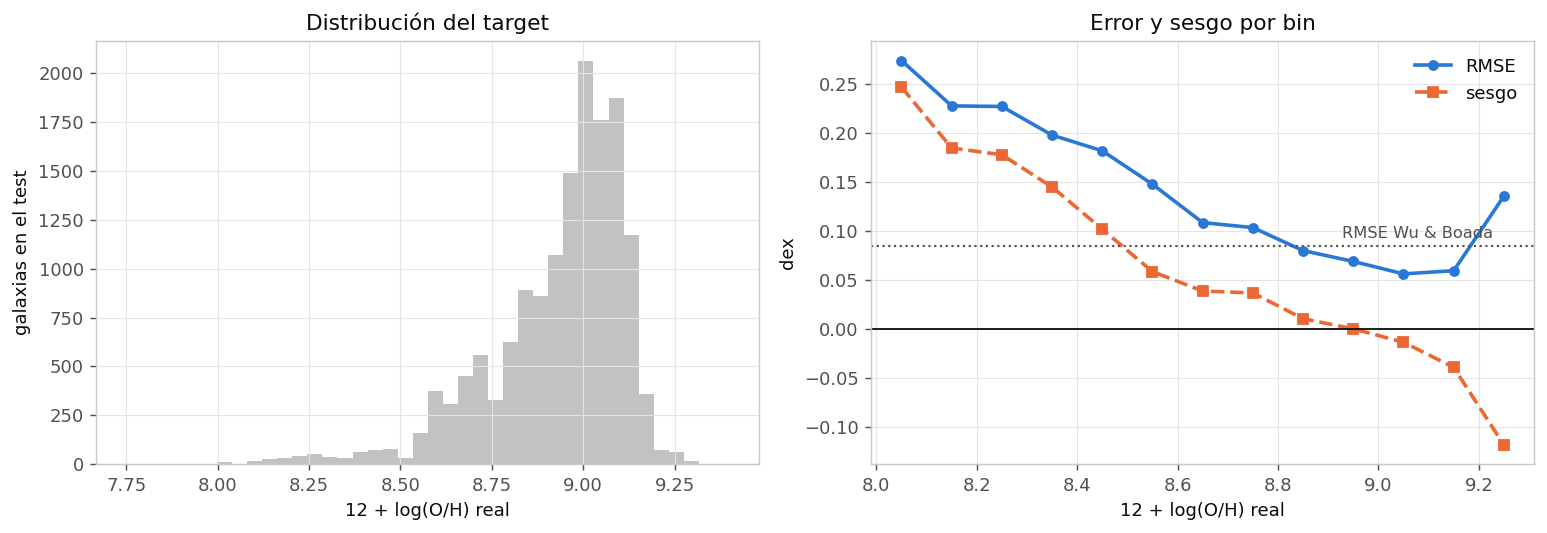

,bin_centro,n,rmse_dex,nmad_dex,sesgo_dex
0,8.05,20,0.2741,0.1363,0.2470
1,8.15,63,0.2278,0.1342,0.1847
2,8.25,107,0.2272,0.1465,0.1778
3,8.35,101,0.1979,0.1179,0.1448
4,8.45,186,0.1819,0.1364,0.1017
5,8.55,366,0.1477,0.1056,0.0584
6,8.65,959,0.1085,0.0821,0.0386
7,8.75,1056,0.1034,0.0857,0.0366
8,8.85,2144,0.0799,0.0755,0.0103
9,8.95,3412,0.0688,0.0626,-0.0001


In [6]:
por_bin = metricas_por_bin(y_real, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Izquierda: cuántas galaxias hay en cada bin
ax1.hist(y_real, bins=40, color=TINTA_SUAVE, alpha=0.35, edgecolor="none")
ax1.set_xlabel("12 + log(O/H) real")
ax1.set_ylabel("galaxias en el test")
ax1.set_title("Distribución del target")

# Derecha: error y sesgo por bin
ax2.plot(por_bin["bin_centro"], por_bin["rmse_dex"], color=AZUL,
         marker="o", markersize=5, label="RMSE")
ax2.plot(por_bin["bin_centro"], por_bin["sesgo_dex"], color=NARANJO,
         marker="s", markersize=5, ls="--", label="sesgo")
ax2.axhline(0, color=TINTA, lw=1)
ax2.axhline(WU_RMSE, color=TINTA_SUAVE, ls=":", lw=1.2)
ax2.annotate("RMSE Wu & Boada", (por_bin["bin_centro"].iloc[-1], WU_RMSE),
             xytext=(-6, 4), textcoords="offset points",
             ha="right", color=TINTA_SUAVE, fontsize=9)
ax2.set_xlabel("12 + log(O/H) real")
ax2.set_ylabel("dex")
ax2.set_title("Error y sesgo por bin")
ax2.legend()

plt.tight_layout()
plt.show()

por_bin[["bin_centro", "n", "rmse_dex", "nmad_dex", "sesgo_dex"]].round(4)

El patrón esperable es un **sesgo con pendiente negativa**: el modelo
sobreestima en el extremo pobre en metales y subestima en el rico. Es regresión
a la media, y aparece también en la Figura 3 del paper. No es un bug; es lo que
hace un estimador que minimiza el error cuadrático cuando la señal es ruidosa.

## 3. ¿Hay sistemáticos escondidos?

Si el residuo correlaciona con alguna propiedad física, el modelo tiene un sesgo
que no se ve en la métrica global. Wu & Boada reportan *no* encontrar
correlaciones significativas del residuo con redshift, color o razón de ejes.

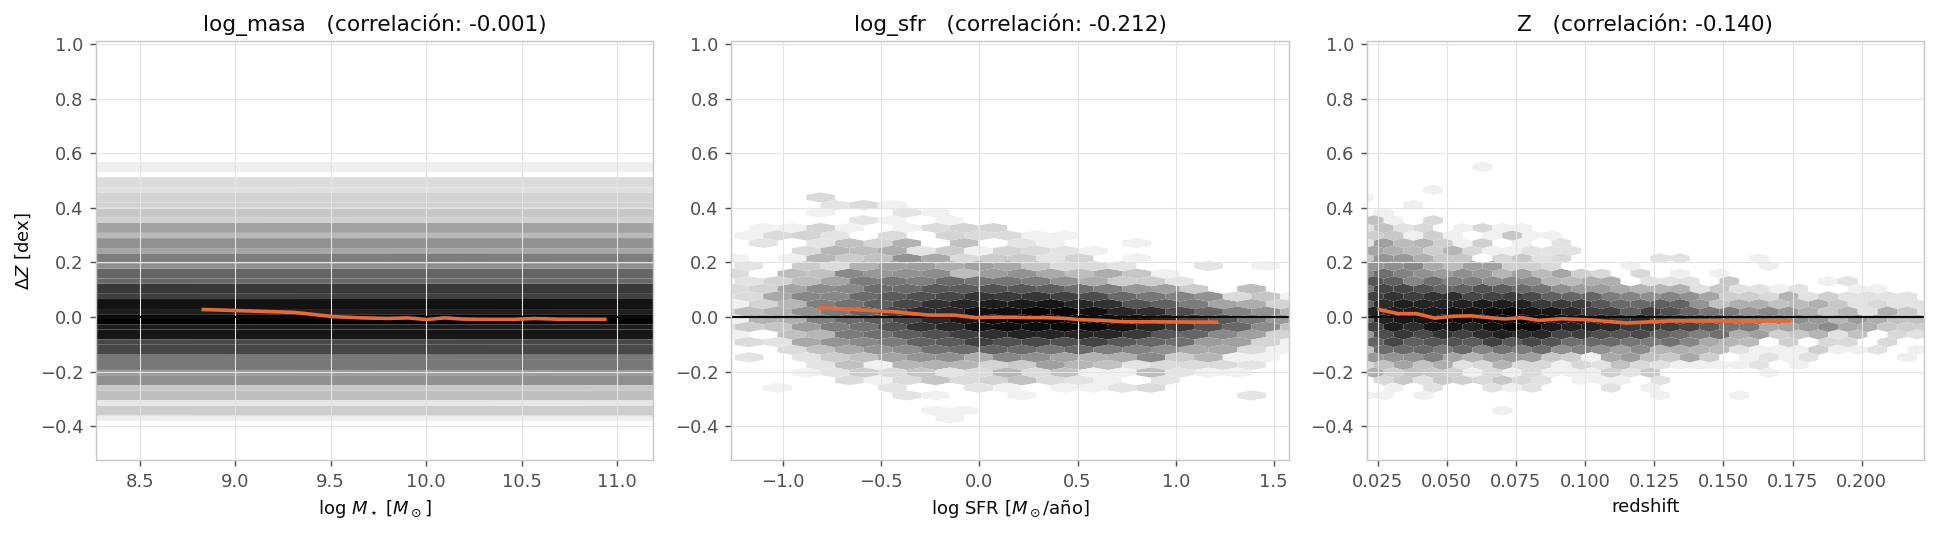

In [7]:
residuo = y_pred - y_real

propiedades = [
    ("log_masa", r"log $M_\star$ [$M_\odot$]"),
    ("log_sfr", r"log SFR [$M_\odot$/año]"),
    ("Z", "redshift"),
]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, (col, etiqueta) in zip(axs, propiedades):
    ok = np.isfinite(test[col]) & np.isfinite(residuo)
    x = test.loc[ok, col].to_numpy()
    r = residuo[ok.to_numpy()]

    ax.hexbin(x, r, gridsize=45, cmap=DENSIDAD, norm=LogNorm(), mincnt=1, linewidths=0)
    ax.axhline(0, color=TINTA, lw=1.2)

    # Mediana móvil del residuo: si se aleja de cero, hay un sistemático.
    bordes = np.percentile(x, np.linspace(1, 99, 16))
    centros, medianas = [], []
    idx = np.digitize(x, bordes) - 1
    for i in range(len(bordes) - 1):
        m = idx == i
        if m.sum() >= 20:
            centros.append((bordes[i] + bordes[i + 1]) / 2)
            medianas.append(np.median(r[m]))
    ax.plot(centros, medianas, color=NARANJO, lw=2)

    rho = np.corrcoef(x, r)[0, 1]
    ax.set_xlabel(etiqueta)
    ax.set_ylabel(r"$\Delta Z$ [dex]" if ax is axs[0] else "")
    ax.set_title(f"{col}   (correlación: {rho:+.3f})")
    ax.set_xlim(np.percentile(x, 0.5), np.percentile(x, 99.5))

plt.tight_layout()
plt.show()

Una correlación con `log_masa` es esperable y no es un defecto: la metalicidad
*está* correlacionada con la masa, así que la regresión a la media se proyecta
sobre ella. Lo preocupante sería una tendencia fuerte con **redshift**, porque
eso indicaría que el modelo está leyendo el tamaño aparente o el brillo
superficial en vez de física.

## 4. La prueba de fondo: el MZR predicho

Acá está el argumento más interesante del paper.

Si se construye la relación masa-metalicidad usando las metalicidades
**predichas** por la CNN, y su dispersión resulta comparable a la del MZR
empírico, entonces las predicciones no pueden diferir del valor real de forma
puramente aleatoria — el ruido habría inflado la dispersión. Eso implica que la
CNN aprendió una representación de la metalicidad genuinamente ligada a la luz
de la galaxia.

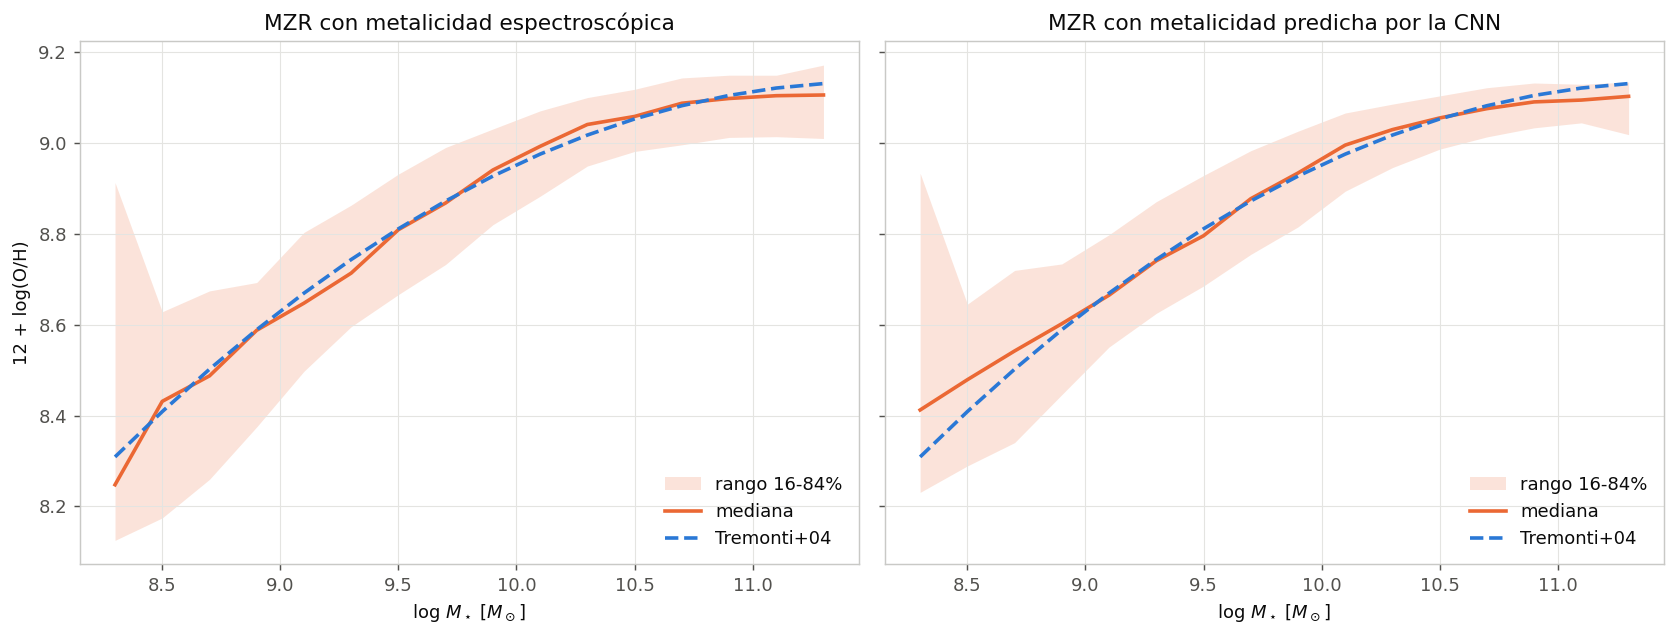

Dispersión media del MZR (16-84%)/2:
  con metalicidad real    : 0.1355 dex
  con metalicidad predicha: 0.1168 dex
  razón predicha/real     : 0.862


In [8]:
def relacion_mzr(log_masa, z, bordes):
    idx = np.digitize(log_masa, bordes) - 1
    centros, p16, p50, p84 = [], [], [], []
    for i in range(len(bordes) - 1):
        m = idx == i
        if m.sum() >= 20:
            centros.append((bordes[i] + bordes[i + 1]) / 2)
            p16.append(np.percentile(z[m], 16))
            p50.append(np.percentile(z[m], 50))
            p84.append(np.percentile(z[m], 84))
    return [np.asarray(v) for v in (centros, p16, p50, p84)]


masa = test.loc[masa_ok, "log_masa"].to_numpy()
bordes = np.arange(np.floor(masa.min()*10)/10, masa.max() + 0.2, 0.2)

c_real, lo_real, med_real, hi_real = relacion_mzr(masa, y_real[masa_ok], bordes)
c_pred, lo_pred, med_pred, hi_pred = relacion_mzr(masa, y_pred[masa_ok], bordes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (cc, lo, med, hi, titulo) in zip((ax1, ax2), [
    (c_real, lo_real, med_real, hi_real, "MZR con metalicidad espectroscópica"),
    (c_pred, lo_pred, med_pred, hi_pred, "MZR con metalicidad predicha por la CNN"),
]):
    ax.fill_between(cc, lo, hi, color=NARANJO, alpha=0.18, linewidth=0,
                    label="rango 16-84%")
    ax.plot(cc, med, color=NARANJO, label="mediana")
    ax.plot(cc, mzr_tremonti(cc), color=AZUL, ls="--", label="Tremonti+04")
    ax.set_xlabel(r"log $M_\star$ [$M_\odot$]")
    ax.set_title(titulo)
    ax.legend(loc="lower right")

ax1.set_ylabel("12 + log(O/H)")
plt.tight_layout()
plt.show()

disp_real = np.mean(hi_real - lo_real) / 2
disp_pred = np.mean(hi_pred - lo_pred) / 2
print(f"Dispersión media del MZR (16-84%)/2:")
print(f"  con metalicidad real    : {disp_real:.4f} dex")
print(f"  con metalicidad predicha: {disp_pred:.4f} dex")
print(f"  razón predicha/real     : {disp_pred/disp_real:.3f}")

**Cómo leerlo.** Si la razón es cercana a 1 o menor, el MZR construido con las
predicciones es tan compacto como el empírico. Wu & Boada encuentran exactamente
eso y argumentan que, dado que sus predicciones difieren de las verdaderas en
0.085 dex, la única forma de que el MZR predicho conserve esa estrechez es que
la CNN haya aprendido algo realmente ligado a la distribución de luz.

Una razón bastante menor que 1 indica lo contrario y es una señal de alerta: el
modelo estaría comprimiendo su rango de predicción hacia la mediana, lo que hace
que *cualquier* relación construida con él se vea artificialmente estrecha.

## 5. Dónde falla el modelo

Las galaxias peor predichas suelen ser informativas: artefactos, fuentes
superpuestas, objetos mal clasificados.

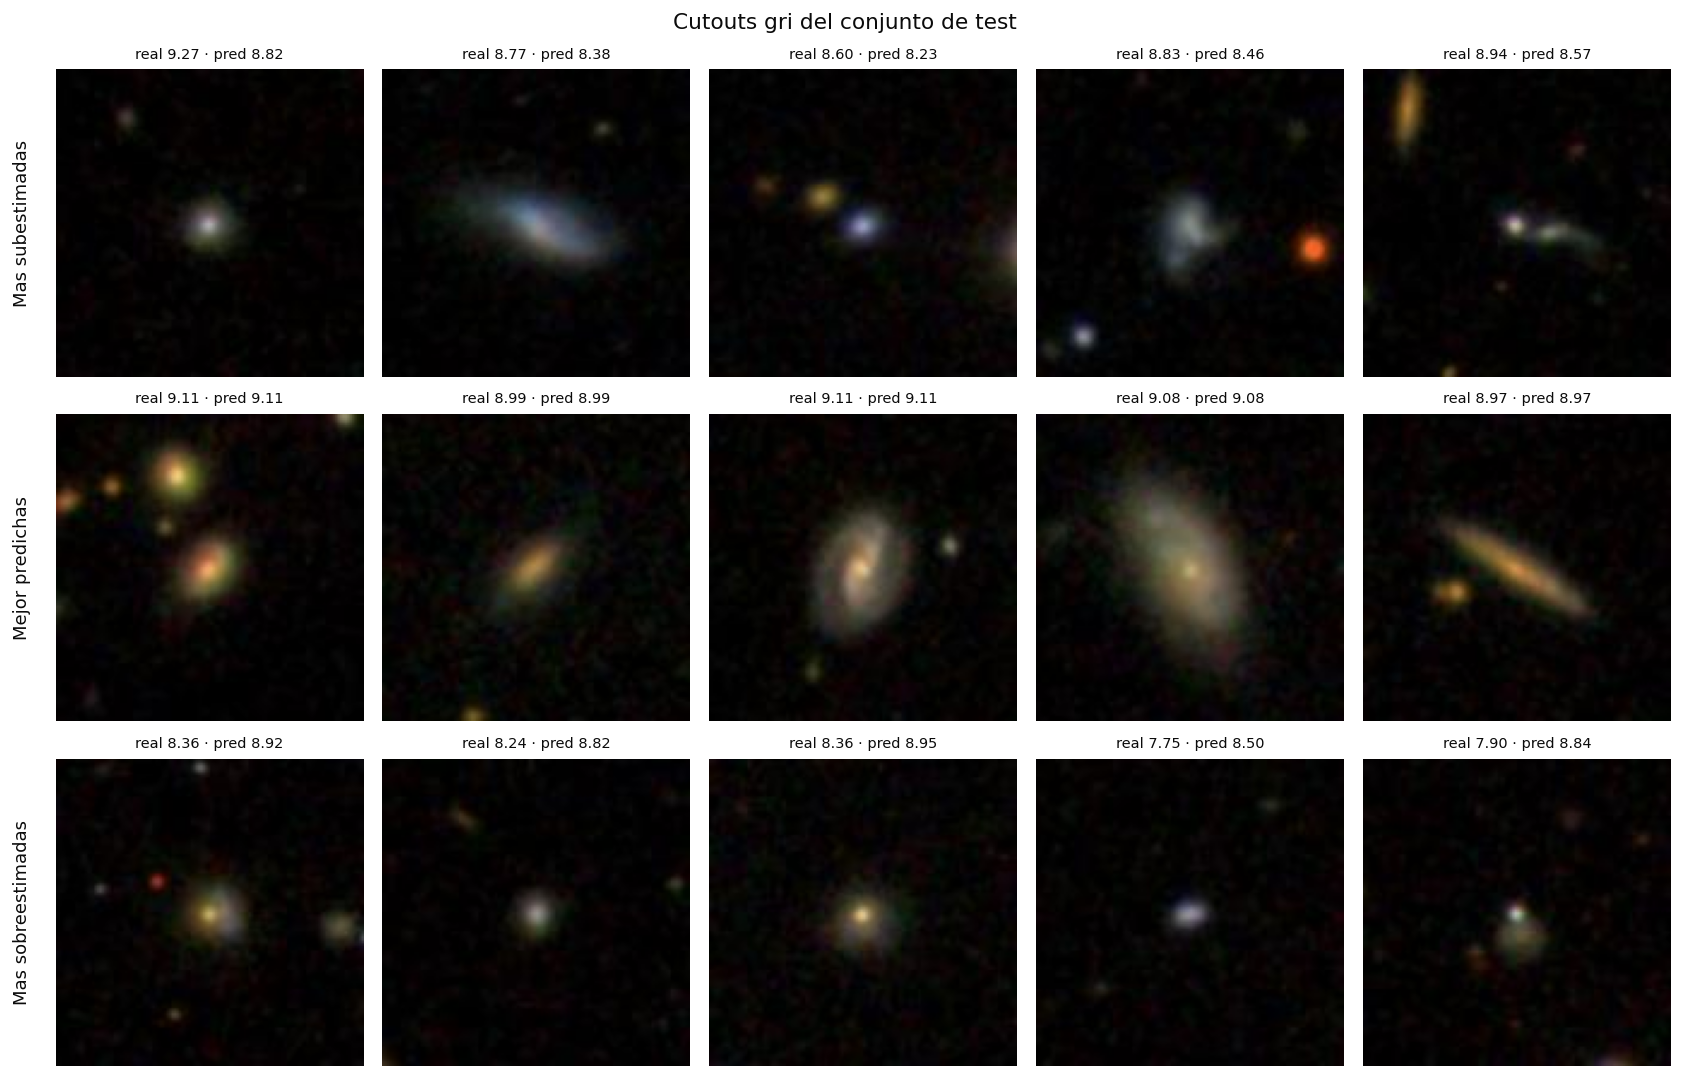

In [9]:
# Las imagenes completas son 4.6 GB y no se versionan. El repo incluye solo las
# 15 que esta celda necesita (data/processed/galeria_ejemplos.npz), para que el
# notebook corra igual fuera del entorno donde se descargaron.
ruta_completa = ruta_absoluta("data/processed/imagenes.npy")
ruta_subset = ruta_absoluta("data/processed/galeria_ejemplos.npz")

orden = np.argsort(residuo)
seleccion = {
    "Mas subestimadas": orden[:5],
    "Mejor predichas": np.argsort(np.abs(residuo))[:5],
    "Mas sobreestimadas": orden[-5:],
}

if ruta_completa.exists():
    imagenes = np.load(ruta_completa, mmap_mode="r")
    def cutout(i):
        return imagenes[test.loc[i, "fila"]]
else:
    sub = np.load(ruta_subset)
    por_fila = dict(zip(sub["filas"].tolist(), sub["imagenes"]))
    def cutout(i):
        return por_fila[int(test.loc[i, "fila"])]

fig, axs = plt.subplots(3, 5, figsize=(13, 8.5))
for fila, (titulo, indices) in zip(axs, seleccion.items()):
    for ax, i in zip(fila, indices):
        ax.imshow(cutout(i))
        ax.set_title(f"real {y_real[i]:.2f} · pred {y_pred[i]:.2f}", fontsize=8)
        ax.axis("off")
    fila[0].text(-0.08, 0.5, titulo, transform=fila[0].transAxes,
                 rotation=90, va="center", ha="right", fontsize=10)

fig.suptitle("Cutouts gri del conjunto de test", fontsize=12)
plt.tight_layout()
plt.show()


### Qué se ve en los casos extremos

El patrón no es aleatorio:

- **Las más subestimadas** (metalicidad real alta, predicción baja) son galaxias
  azules e irregulares, varias con una compañera cercana que sugiere
  interacción. La red lee el color azul como "pobre en metales", que es la
  heurística correcta en general, pero en estos sistemas el color está dominado
  por un brote de formación estelar reciente y no por la metalicidad del gas.

- **Las mejor predichas** son espirales clásicas, bien resueltas y de tonos
  rojizos. La red acierta al segundo decimal.

- **Las más sobreestimadas** son objetos compactos y poco resueltos, donde
  simplemente hay menos información morfológica que extraer, y el modelo cae
  hacia el valor típico de la muestra.

Coincide con lo que describen Wu & Boada: sus peores casos también son objetos
con gradientes de color no físicos o morfologías atípicas. El modelo falla donde
la heurística visual que aprendió deja de valer.

## 6. Resumen

In [10]:
print(f"CNN        RMSE {m_cnn['rmse_dex']:.4f} dex   NMAD {m_cnn['nmad_dex']:.4f} dex")
print(f"Baseline   RMSE {m_media['rmse_dex']:.4f} dex   (predecir la media)")
print(f"MZR real   RMSE {m_mzr['rmse_dex']:.4f} dex   (Tremonti+04 con masa medida)")
print(f"Wu & Boada RMSE {WU_RMSE:.4f} dex   NMAD {WU_NMAD:.4f} dex")
print()
print(f"Sesgo global: {m_cnn['sesgo_dex']:+.4f} dex")
print(f"Razón de dispersión del MZR (predicho/real): {disp_pred/disp_real:.3f}")

CNN        RMSE 0.0841 dex   NMAD 0.0624 dex
Baseline   RMSE 0.1881 dex   (predecir la media)
MZR real   RMSE 0.1253 dex   (Tremonti+04 con masa medida)
Wu & Boada RMSE 0.0850 dex   NMAD 0.0670 dex

Sesgo global: +0.0022 dex
Razón de dispersión del MZR (predicho/real): 0.862
